
Stage 1
---



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = sns.load_dataset('diamonds')
print(df.shape)
print(df[(df['x'] == 0) | (df['y'] == 0) | (df['z'] == 0)])
df_clean = df[(df['x'] > 0) & (df['y'] > 0) & (df['z'] > 0)].copy()
kolom_dimensi = ['x', 'y', 'z']

for col in kolom_dimensi:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    batas_bawah = Q1 - 1.5 * IQR
    batas_atas = Q3 + 1.5 * IQR

    df_clean = df_clean[(df_clean[col] >= batas_bawah) & (df_clean[col] <= batas_atas)]

(53940, 10)
       carat        cut color clarity  depth  table  price     x     y    z
2207    1.00    Premium     G     SI2   59.1   59.0   3142  6.55  6.48  0.0
2314    1.01    Premium     H      I1   58.1   59.0   3167  6.66  6.60  0.0
4791    1.10    Premium     G     SI2   63.0   59.0   3696  6.50  6.47  0.0
5471    1.01    Premium     F     SI2   59.2   58.0   3837  6.50  6.47  0.0
10167   1.50       Good     G      I1   64.0   61.0   4731  7.15  7.04  0.0
11182   1.07      Ideal     F     SI2   61.6   56.0   4954  0.00  6.62  0.0
11963   1.00  Very Good     H     VS2   63.3   53.0   5139  0.00  0.00  0.0
13601   1.15      Ideal     G     VS2   59.2   56.0   5564  6.88  6.83  0.0
15951   1.14       Fair     G     VS1   57.5   67.0   6381  0.00  0.00  0.0
24394   2.18    Premium     H     SI2   59.4   61.0  12631  8.49  8.45  0.0
24520   1.56      Ideal     G     VS2   62.2   54.0  12800  0.00  0.00  0.0
26123   2.25    Premium     I     SI1   61.3   58.0  15397  8.52  8.42  0.0


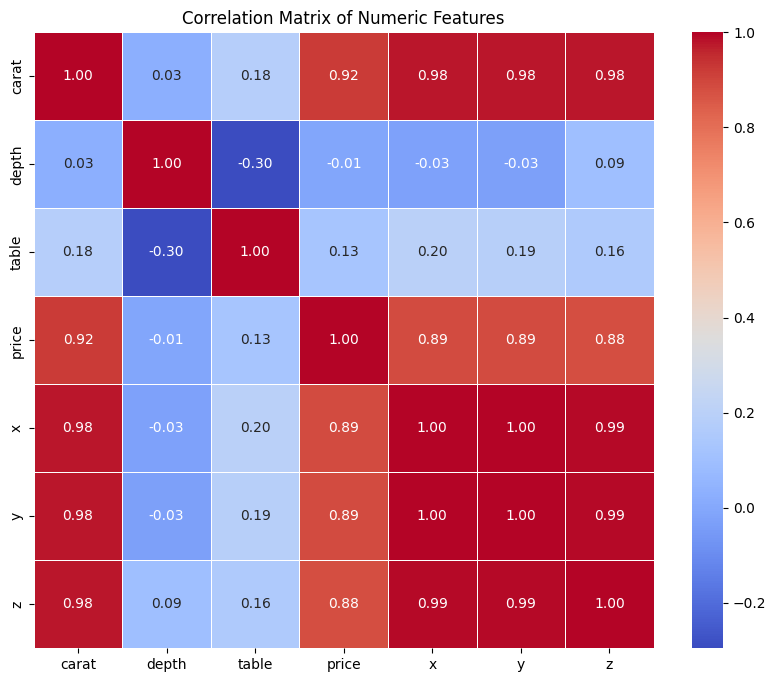

carat    0.923381
y        0.888434
x        0.886838
z        0.881898
table    0.126559
depth   -0.012113
Name: price, dtype: float64


In [ ]:
corr_matrix = df_clean.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Numeric Features')
plt.show()
corr_price = corr_matrix['price'].drop('price').sort_values(ascending=False)

print(corr_price)

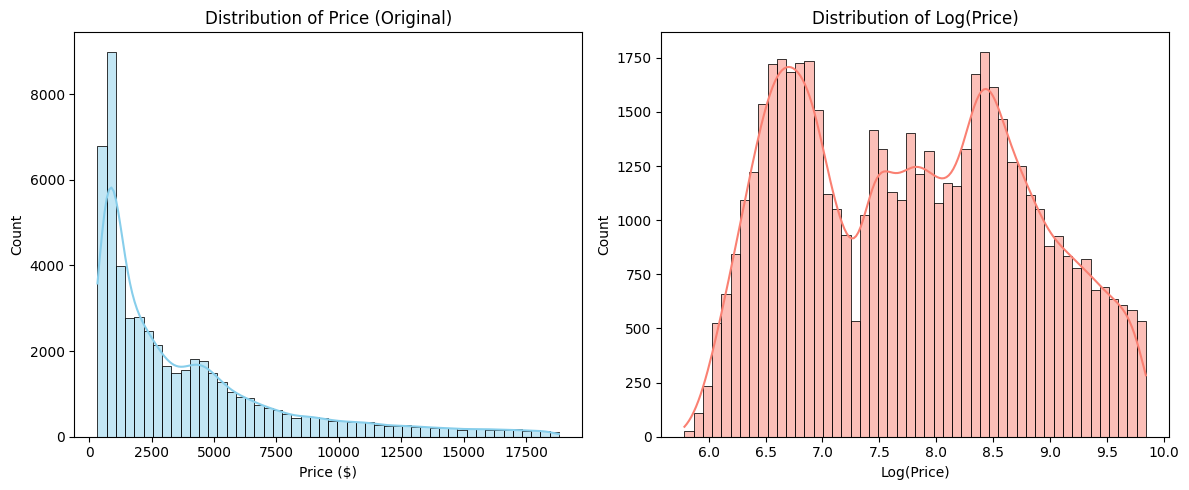

In [ ]:
#kanvas 1 baris dan 2 kolom
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df_clean['price'], bins=50, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Price (Original)')
axes[0].set_xlabel('Price ($)')

log_price = np.log(df_clean['price'])
sns.histplot(log_price, bins=50, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribution of Log(Price)')
axes[1].set_xlabel('Log(Price)')

plt.tight_layout()
plt.show()

A log-transform is needed because the original distribution of the price is heavily right-skewed, meaning the vast majority of diamonds are concentrated at lower price points, with a long tail of rare, highly-priced diamonds. A log-transform mathematically compresses these extreme high values, pulling the long tail inward. As a result, the curve becomes much more symmetric and closely resembles a normal (bell-shaped) distribution.

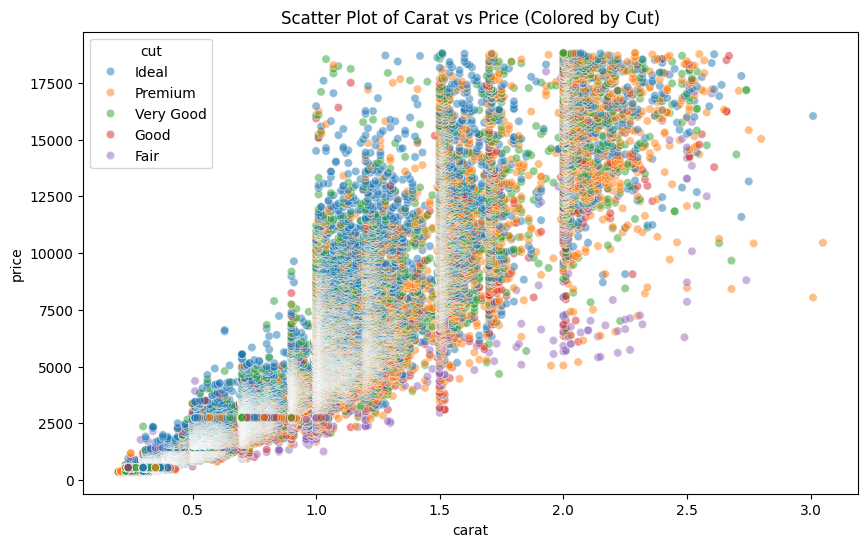

In [ ]:
plt.figure(figsize=(10, 6))

#carat di sumbu X, price di sumbu Y, dan diwarnai berdasarkan cut
sns.scatterplot(data=df_clean, x='carat', y='price', hue='cut', alpha=0.5)

plt.title('Scatter Plot of Carat vs Price (Colored by Cut)')
plt.show()

The relationship is not strictly linear. The scatter plot shows an upward curve (non-linear/polynomial trend). This indicates that as the carat weight increases, the price increases at a faster, almost exponential rate rather than following a constant straight line.

If we observe a specific carat weight (by looking at a vertical slice on the graph), we can see a wide vertical spread of points with different colors. This shows that diamonds with the exact same carat weight can have significantly different prices, and this variance is largely driven by the quality of the cut.

Stage 2

In [ ]:
from sklearn.model_selection import train_test_split

X = df_clean[['carat', 'depth', 'table', 'x', 'y', 'z']]
y = np.log(df_clean['price'])
#80% train 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

pipe.fit(X_train, y_train)

y_train_pred = pipe.predict(X_train)
train_mae = mean_absolute_error(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_r2 = r2_score(y_train, y_train_pred)

print("Train result:")
print(f"MAE: {train_mae:.2f}")
print(f"RMSE: {train_rmse:.2f}")
print(f"R^2: {train_r2:.4f}\n")

y_test_pred = pipe.predict(X_test)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred)

print("Test result:")
print(f"MAE: {test_mae:.4f}")
print(f"RMSE: {test_rmse:.4f}")
print(f"R^2: {test_r2:.4f}")

Train result:
MAE: 0.20
RMSE: 0.26
R^2: 0.9368

Test result:
MAE: 0.2000
RMSE: 0.2551
R^2: 0.9350


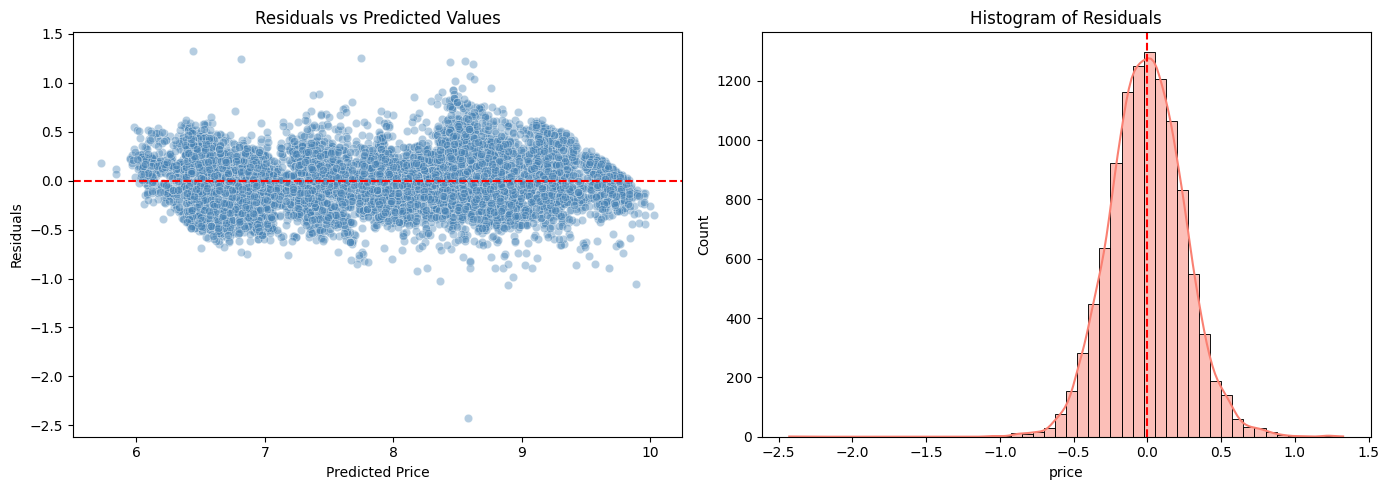

In [ ]:
residuals = y_test - y_test_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Plot Residual vs Predicted
sns.scatterplot(x=y_test_pred, y=residuals, alpha=0.4, ax=axes[0], color='steelblue')
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Residuals vs Predicted Values')
axes[0].set_xlabel('Predicted Price')
axes[0].set_ylabel('Residuals')

# (b) Histogram Residual
sns.histplot(residuals, bins=50, kde=True, ax=axes[1], color='salmon')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Histogram of Residuals')

plt.tight_layout()
plt.show()

In [ ]:
koefisien = pipe.named_steps['model'].coef_
nama_fitur = X.columns

df_coef = pd.DataFrame({
    'Feature': nama_fitur,
    'Coefficient': koefisien
})
df_coef['Abs_Coefficient'] = df_coef['Coefficient'].abs()
df_coef = df_coef.sort_values(by='Abs_Coefficient', ascending=False).drop(columns=['Abs_Coefficient'])

print(df_coef)

  Feature  Coefficient
4       y     0.719173
0   carat    -0.506805
5       z     0.418083
3       x     0.344348
2   table    -0.016531
1   depth    -0.001119


The feature with the greatest influence is y (the width of the diamond) with a coefficient of 0.719173.

Any coefficients counterintuitive in sign. Notice the coefficient for carat, its value is negative (-0.506805). This is highly counterintuitive. According to standard business logic, the heavier a diamond is (as carat increases), the more expensive it should be (meaning the coefficient should naturally be positive). However, this model is essentially saying, "assuming all other dimensions remain constant, the heavier the diamond, the lower the price."

Stage 3

In [ ]:
X_poly = df_clean[['carat']]
y_poly = np.log(df_clean['price'])
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X_poly, y_poly, test_size=0.2, random_state=42)

degrees = [1, 2, 3, 5]
results = []
models = {}

for d in degrees:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('poly', PolynomialFeatures(degree=d, include_bias=False)),
        ('model', LinearRegression())
    ])

    pipe.fit(X_train_p, y_train_p)
    models[d] = pipe

    y_train_pred = pipe.predict(X_train_p)
    y_test_pred = pipe.predict(X_test_p)

    r2_train = r2_score(y_train_p, y_train_pred)
    r2_test = r2_score(y_test_p, y_test_pred)
    rmse_test = np.sqrt(mean_squared_error(y_test_p, y_test_pred))

    results.append({
        'Degree': d,
        'R² Train': r2_train,
        'R² Test': r2_test,
        'RMSE Test': rmse_test
    })

df_results = pd.DataFrame(results)
display(df_results)

,Degree,R² Train,R² Test,RMSE Test
0,1,0.853612,0.855610,0.380353
1,2,0.933336,0.931795,0.261414
2,3,0.936097,0.934438,0.256297
3,5,0.936446,0.934666,0.255852


/tmp/ipykernel_798/2837384397.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  x_plot = np.linspace(X_poly.min()[0], X_poly.max()[0], 200).reshape(-1, 1)


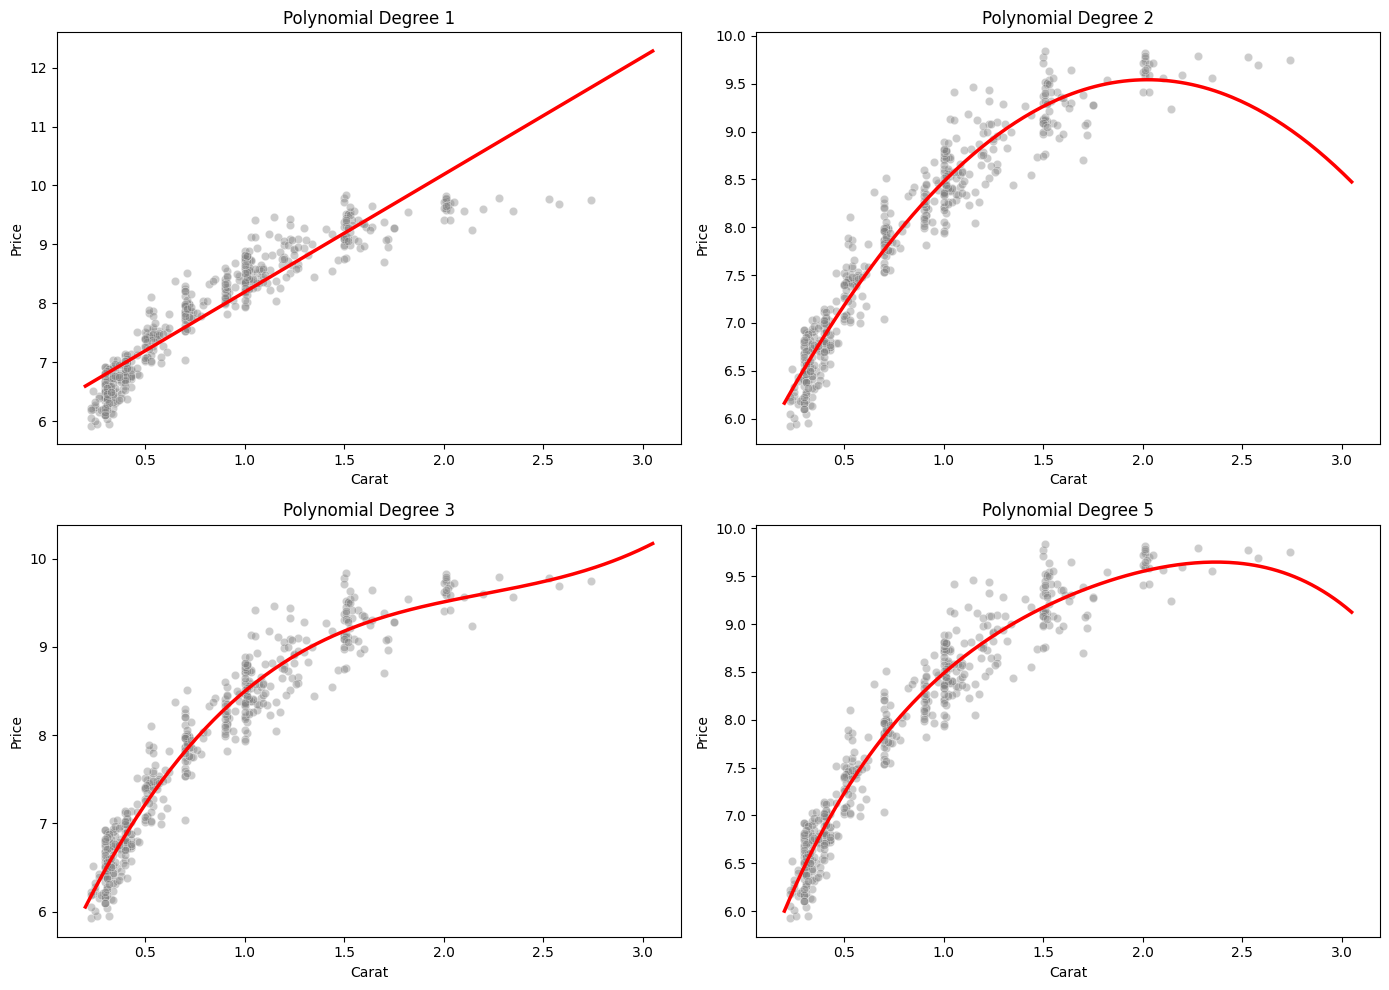

In [ ]:
sample_idx = X_train_p.sample(500, random_state=42).index
X_sample = X_train_p.loc[sample_idx]
y_sample = y_train_p.loc[sample_idx]

x_plot = np.linspace(X_poly.min()[0], X_poly.max()[0], 200).reshape(-1, 1)
x_plot_df = pd.DataFrame(x_plot, columns=['carat']) # Ubah ke DataFrame agar sklearn tidak warning

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, d in enumerate(degrees):
    ax = axes[i]

    sns.scatterplot(x=X_sample['carat'], y=y_sample, alpha=0.4, color='gray', ax=ax)

    y_plot_pred = models[d].predict(x_plot_df)
    ax.plot(x_plot_df['carat'], y_plot_pred, color='red', linewidth=2.5)

    ax.set_title(f'Polynomial Degree {d}')
    ax.set_xlabel('Carat')
    ax.set_ylabel('Log(Price)' if 'log' in str(y_poly.name).lower() else 'Price')

plt.tight_layout()
plt.show()

Degree 3 is the optimal model. Degree 3 has a very high Test R² of 0.934438 and a low Test RMSE of 0.256297. This is a significant improvement over both Degree 1 (Test R² 0.855610) and Degree 2 (Test R² 0.931795). On the Polynomial Degree 3 graph, the curve follows the data distribution very naturally. The price continues to show an upward or flattening trend as the size (Carat) increases, which makes perfect logical sense in the real world.

Degree 5 clearly exhibits overfitting when evaluated alongside its visual interpretation. At first glance, Degree 5's metrics might look slightly better (Train R² 0.936446 and Test R² 0.934666). However, the performance gap between the training and testing data is larger compared to Degree 3, which is an early indication that the model is starting to "memorize" the training data. The most fatal evidence of overfitting is seen in its graph. In the Polynomial Degree 5 plot, the right end of the curve (as Carat approaches 3.0) sharply dives downward. From a business logic perspective, it is impossible for diamonds to suddenly become drastically cheaper as they get larger. The model is overly complex, forcing itself to bend and fit a few scattered data points in that area instead of capturing the underlying main trend.

Stage 4

Stage 2 uses multiple variables at once (like carat, x, y, z, etc.). Mathematically, a model given more variables will almost always produce a slightly smaller error on both training and test data because it has more ways to "fit" itself to the data. As you discovered earlier, using carat alongside x, y, and z confuses the model because they all measure the exact same thing (physical dimensions). As a result, the Stage 2 model produces illogical coefficients (for instance, assigning negative weights to size variables).

When building real-world, solution-oriented products, a model with broken internal logic—even if its error margin is 0.001 lower—is highly dangerous to rely on for business pricing. Therefore, Stage 3 (Polynomial) remains the absolute winner because it is mathematically robust and perfectly aligned with sound business logic.

Business Insights on Diamond Pricing Strategy

Business Logic Over Raw Metrics: While our initial Multiple Linear Regression model yielded a microscopically lower error rate, it relied on overlapping metrics (like using weight, length, and width simultaneously) which broke the internal logic of the pricing algorithm. We deliberately chose the Polynomial model because it provides a vastly more robust and structurally sound pricing foundation, sacrificing a negligible 0.001 in accuracy to ensure prices are never calculated using contradictory rules.

Size Drives Value Exponentially, Not Linearly: The relationship between a diamond's weight (carat) and its price is not a simple straight line. As diamonds get larger, they become exponentially rarer. Our selected polynomial model successfully captures this natural, real-world market curve.

Safeguarding Against Illogical Forecasting: We carefully tested how complex our forecasting should be. If a model is made too complex, it mistakenly predicts that massive, extremely rare diamonds will suddenly drop in price. We selected an optimal "Degree 3" model that guarantees our price estimates remain consistently realistic and highly profitable across all diamond sizes.